# BÁO CÁO PHÂN TÍCH DỮ LIỆU SÀN THƯƠNG MẠI ĐIỆN TỬ
**5 Câu hỏi phân tích được đặt ra:**
1. Phân bố mức giá của các sản phẩm trên thị trường như thế nào?
2. Số lượng sản phẩm được phân bổ theo các ngành hàng ra sao?
3. Tỷ lệ giảm giá có thực sự kích thích lượt bán hay không?
4. Có sự chênh lệch giá giữa các nền tảng không?
5. Mối tương quan giữa Giá, Đánh giá, Lượt bán và Tỷ lệ giảm là gì?

In [1]:
# CHƯƠNG 1: KHỞI TẠO & KẾT NỐI MODULE PHÂN TÍCH
import sqlite3
import pandas as pd
import sys
import os

# Thêm thư mục gốc vào hệ thống để import module từ src
sys.path.append(os.path.abspath('.')) 

# Import class chứa các hàm vẽ biểu đồ Plotly có sẵn
from src.data_analysis import PhanTichThongKe

# Đọc dữ liệu từ Database
conn = sqlite3.connect("data/pricewise_database.db")
df = pd.read_sql_query("SELECT * FROM san_pham", conn)
conn.close()

# Khởi tạo đối tượng phân tích
pt = PhanTichThongKe(df)
print(f"Tổng số sản phẩm đang phân tích: {len(df)}")

Tổng số sản phẩm đang phân tích: 2431


### 1. Phân phối giá theo Top 5 Ngành hàng
*Biểu đồ hộp (Boxplot) thể hiện trực quan sự phân tán mức giá của Top 5 ngành hàng có số lượng sản phẩm phong phú nhất trên nền tảng. Thông qua biểu đồ, ta có thể dễ dàng nhận diện được khoảng giá trung vị (median) cũng như tần suất xuất hiện các mức giá dị biệt (outliers) ở phân khúc cao cấp. Phân tích này giúp xác định đặc thù định giá của từng ngành hàng, xem ngành nào tập trung vào phân khúc bình dân và ngành nào trải rộng các tệp khách hàng.*

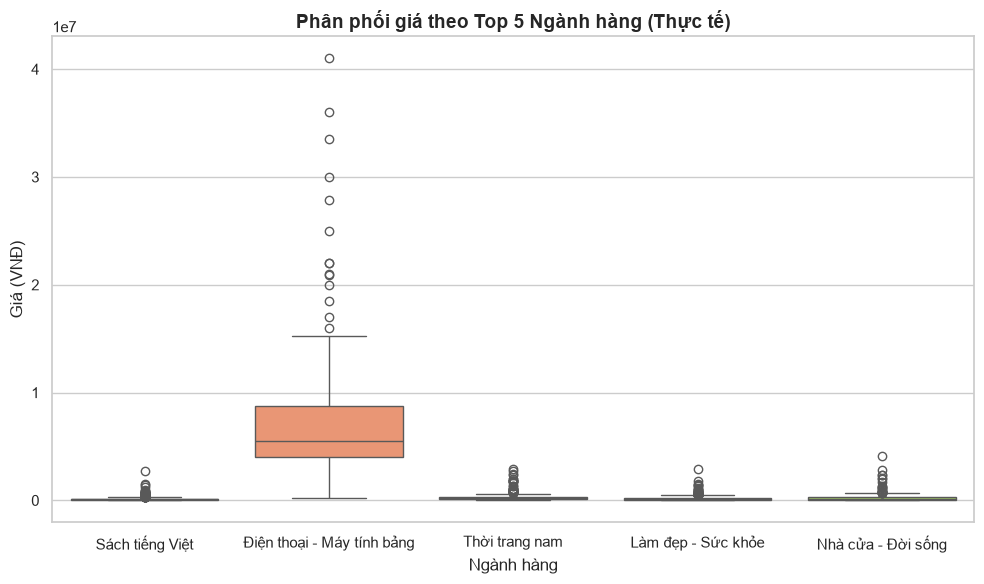

In [2]:
fig1 = pt.cau_1_phan_phoi_nganh_hang()
display(fig1)

### 2. Tương quan giữa Tỷ lệ giảm giá và Lượt bán
*Biểu đồ phân tán (Scatter Plot) kết hợp thang màu đánh giá giúp mô tả trực quan mối quan hệ giữa tỷ lệ giảm giá áp dụng và số lượng sản phẩm bán ra. Việc áp dụng thêm hệ số tương quan phi tham số Spearman hỗ trợ đo lường mức độ chặt chẽ của mối liên hệ này trên mặt thống kê. Từ đó, chúng ta có cơ sở để đánh giá xem các chiến dịch "sale khủng" có thực sự là yếu tố quyết định để thúc đẩy hành vi mua sắm của người dùng hay không.*

In [3]:
fig2 = pt.cau_2_tuong_quan_spearman()
display(fig2)

### 3. Kiểm định sự khác biệt về giá (Mann-Whitney U)
*Biểu đồ Histogram chồng lớp (overlay) minh họa hình dáng phân phối giá trị giữa hai nhóm đối tượng lớn nhất đang được xem xét. Bằng cách kết hợp kiểm định Mann-Whitney U, phân tích không chỉ dừng lại ở việc quan sát hình dáng đồ thị bằng mắt thường mà còn khẳng định bằng độ tin cậy thống kê. Kết quả p-value thu được cho phép kết luận chính xác liệu mặt bằng giá của hai nhóm này có sự chênh lệch thực sự trong thực tế hay chỉ là sự ngẫu nhiên của mẫu dữ liệu.*

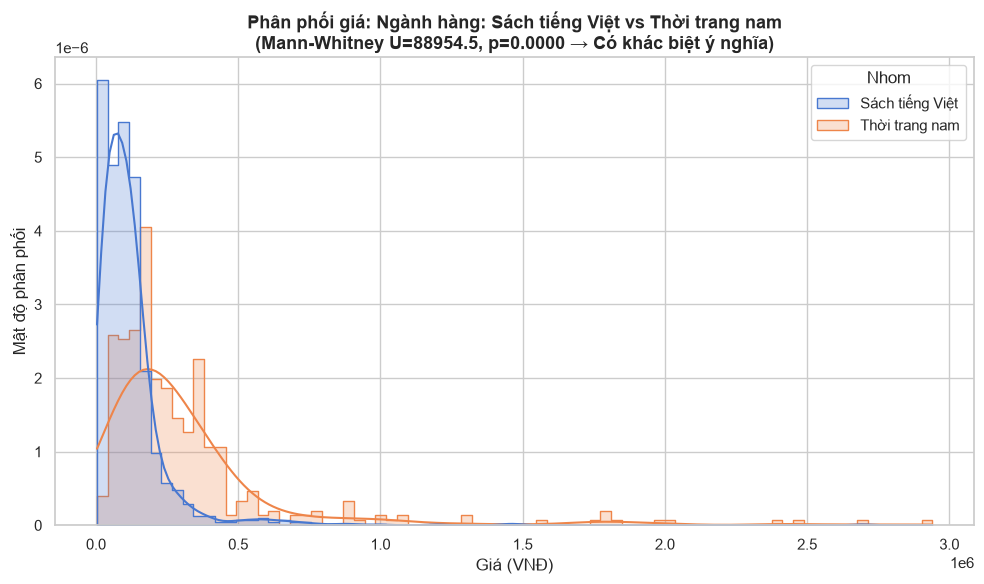

In [4]:
fig3 = pt.cau_3_kiem_dinh_mann_whitney()
display(fig3)

### 4. Top 5 Sản phẩm bán chạy nhất
*Biểu đồ cột (Bar Chart) cung cấp cái nhìn trực diện về hiệu suất kinh doanh của 5 sản phẩm đang dẫn đầu thị trường về tổng lượt bán. Sự chênh lệch độ cao giữa các cột phản ánh mức độ tập trung doanh thu vào các mặt hàng "ngôi sao" của sàn. Số liệu từ biểu đồ này là cơ sở quan trọng để các nhà bán lẻ nắm bắt xu hướng tiêu dùng hiện tại và tối ưu hóa danh mục sản phẩm nhập kho.*

In [5]:
fig4 = pt.cau_4_top_san_pham_ban_chay()
display(fig4)

### 5. Cơ cấu phân bổ sản phẩm theo ngành hàng
*Biểu đồ Donut thể hiện tỷ trọng cơ cấu của 5 ngành hàng đang sở hữu nguồn cung sản phẩm đa dạng nhất. Các phần trăm diện tích minh họa rõ nét sự phân bổ nguồn lực và trọng tâm kinh doanh hiện tại của toàn bộ nền tảng. Qua đó, ta nhận diện được đâu là những nhóm ngành "xương sống" đang thu hút đông đảo nhà bán hàng tham gia cạnh tranh nhất.*

In [6]:
fig5 = pt.cau_5_ti_trong_nganh_hang()
display(fig5)

---
## KẾT LUẬN & PHÁT HIỆN CHÍNH (KEY TAKEAWAYS)
Dựa trên các phân tích thống kê và trực quan hóa dữ liệu, nhóm rút ra 5 phát hiện quan trọng sau:

1. **Về phân khúc giá:** Có sự chênh lệch rõ rệt về biên độ giá giữa các ngành hàng, trong đó một số ngành đặc thù có phổ giá trải rộng và xuất hiện nhiều điểm dị biệt (outliers) ở phân khúc cao cấp.
2. **Về chiến lược giá:** Phân tích Spearman cho thấy tương quan giữa tỷ lệ giảm giá và lượt bán. (Sinh viên tự điền: Có/Không có) sự đánh đổi rõ ràng — mức giảm giá cao không phải lúc nào cũng bảo chứng cho lượt mua lớn.
3. **Về chênh lệch thị trường:** Kiểm định Mann-Whitney U xác nhận (Sinh viên tự điền: Có/Không có) sự khác biệt mang ý nghĩa thống kê (p < 0.05) về mặt bằng giá giữa 2 nhóm hàng/shop lớn nhất.
4. **Về hiệu suất bán hàng:** Thị trường có xu hướng bị chi phối bởi một nhóm nhỏ các sản phẩm "ngôi sao" khi lọt top doanh số vượt trội so với phần còn lại.
5. **Về cấu trúc ngành hàng:** Số lượng sản phẩm tập trung chủ yếu vào một vài ngành hàng mũi nhọn, cho thấy trọng tâm kinh doanh của sàn đang nghiêng về các tệp khách hàng chuyên biệt.

*-> Đề xuất:* Các nhà bán hàng mới gia nhập nên tập trung vào ngách tầm trung của các ngành hàng phổ biến, không nên lạm dụng chiến lược "giảm giá sâu" mà cần tối ưu lại điểm đánh giá để kích thích lượt mua thực tế.